## Note
None of this was used

In [ ]:
df <- read.csv("data/fluview_clean/ilinet_final.csv")

library(forecast)


# Fit ARIMAX: percent_weighted_ili ~ percent_unweighted_ili
library(forecast)

model_df <- df[, c("percent_weighted_ili", "percent_unweighted_ili")]
model_df <- model_df[complete.cases(model_df), ]

y <- ts(df$percent_weighted_ili-df$percent_unweighted_ili, frequency = 52)


# Use a faster search strategy for notebook execution
arima <- auto.arima(
  diff(y),
  seasonal = TRUE,
  stepwise = TRUE,
  approximation = TRUE
)
summary(arima)

In [ ]:
# # The holdout set is the last 104 weeks
# h <- 104

# # Calculate the RMSE for the 1-step-ahead rolling forecast on the training set
# # model_df <- df[, c("percent_weighted_ili", "percent_unweighted_ili")]
# # model_df <- model_df[complete.cases(model_df), ]

# n <- nrow(model_df)
# train_end <- n - h

# # if (train_end <= 105) stop("Not enough observations after reserving holdout set.")

# y_train <- model_df$percent_weighted_ili[1:train_end]
# x_train <- model_df$percent_unweighted_ili[1:train_end]

# y_train_ts <- ts(y_train, frequency = 52)
# x_train_mat <- matrix(x_train, ncol = 1)

# # Select ARIMAX structure once on the training set
# base_fit <- auto.arima(
#   y_train_ts,
#   xreg = x_train_mat,
#   seasonal = TRUE,
#   stepwise = TRUE,
#   approximation = TRUE
# )
# print(summary(base_fit))
# # # Expanding-window 1-step rolling forecasts (fixed ARIMA structure)
# # initial_window <- 104
# # idx <- seq(from = initial_window + 1, to = train_end)
# # errors <- numeric(length(idx))

# # for (k in seq_along(idx)) {
# #   i <- idx[k]

# #   fit_i <- Arima(
# #     ts(y_train[1:(i - 1)], frequency = 52),
# #     model = base_fit,
# #     xreg = matrix(x_train[1:(i - 1)], ncol = 1)
# #   )

# #   fc_i <- forecast(
# #     fit_i,
# #     h = 1,
# #     xreg = matrix(x_train[i], nrow = 1)
# #   )

# #   errors[k] <- y_train[i] - as.numeric(fc_i$mean[1])
# # }

# # rmse_train_1step <- sqrt(mean(errors^2, na.rm = TRUE))
# # rmse_train_1step

In [ ]:
split_data <- function(df_column,frequency=52,start=c(1979,40),holdout_length=104){
  time_series_obj <-ts(df_column, frequency = frequency, start = start)
  n <- length(time_series_obj)
  return (list(
    train = window(time_series_obj, start=start, end=time(time_series_obj)[n-holdout_length]),
    holdout = window(time_series_obj, start=time(time_series_obj)[n-holdout_length+1], end=time(time_series_obj)[n]),
    ts_obj = time_series_obj
  ))
}

values <- split_data(log(df$percent_weighted_ili+1)-mean(log(df$percent_weighted_ili+1)))

weeks <- split_data(df$week,frequency = 52, start = c(1979,40), holdout_length = 104)

week_train = rep(1:12,18)
week_holdout = rep(1:12,5)
week_all = rep(1:12,23)
t_train = 1:length(values$train)
t_holdout = (length(values$train) + 1):(length(values$ts_obj))
t_all = 1:length(values$ts_obj)

percent_weighted_ili <- values$ts_obj

train <- values$train
holdout <- values$holdout



arimax_fc <- function(tsdata,ntrain,order,method,traincoef,include.mean,xreg,
iprint=F){
    obj <<- arima(tsdata,order=order,init=traincoef,fixed=traincoef,
method=method, include.mean=include.mean, xreg=xreg,
optim.control=list(maxit=0))
    fc <- tsdata - obj$residuals
    n_total <- length(tsdata)
    holdout_fc <- fc[(ntrain+1):n_total]
    holdout <- tsdata[(ntrain+1):n_total]
    rmse <- sqrt(mean((expm1(holdout) - expm1(holdout_fc))^2))
    list(rmse=rmse,fc = holdout_fc)
}

train_df <- data.frame(response = train, tt=t_train, cosine = cos(2 * pi * t_train / 52), sine = sin(2 * pi * t_train / 52))
holdout_df <- data.frame(response = holdout, tt=t_holdout, cosine = cos(2 * pi * t_holdout / 52), sine = sin(2 * pi * t_holdout / 52))
all_df <- data.frame(response = percent_weighted_ili,tt = t_all, cosine = cos(2 * pi * t_all / 52), sine = sin(2 * pi * t_all / 52))
reg_tt_cossin = lm(response~ tt+cosine+sine, data=train_df)
summary(reg_tt_cossin)


Call:
lm(formula = response ~ tt + cosine + sine, data = train_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.81428 -0.17154 -0.00459  0.13942  1.22070 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.661e-01  1.502e-02  -17.72   <2e-16 ***
tt           3.453e-04  1.887e-05   18.30   <2e-16 ***
cosine      -2.968e-01  1.061e-02  -27.96   <2e-16 ***
sine         3.790e-01  1.062e-02   35.70   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2786 on 1374 degrees of freedom
Multiple R-squared:  0.6351,	Adjusted R-squared:  0.6343 
F-statistic: 797.1 on 3 and 1374 DF,  p-value: < 2.2e-16


I want to build a model now that instead uses only the current and previous x value as well as the previous y value to predict the current y value

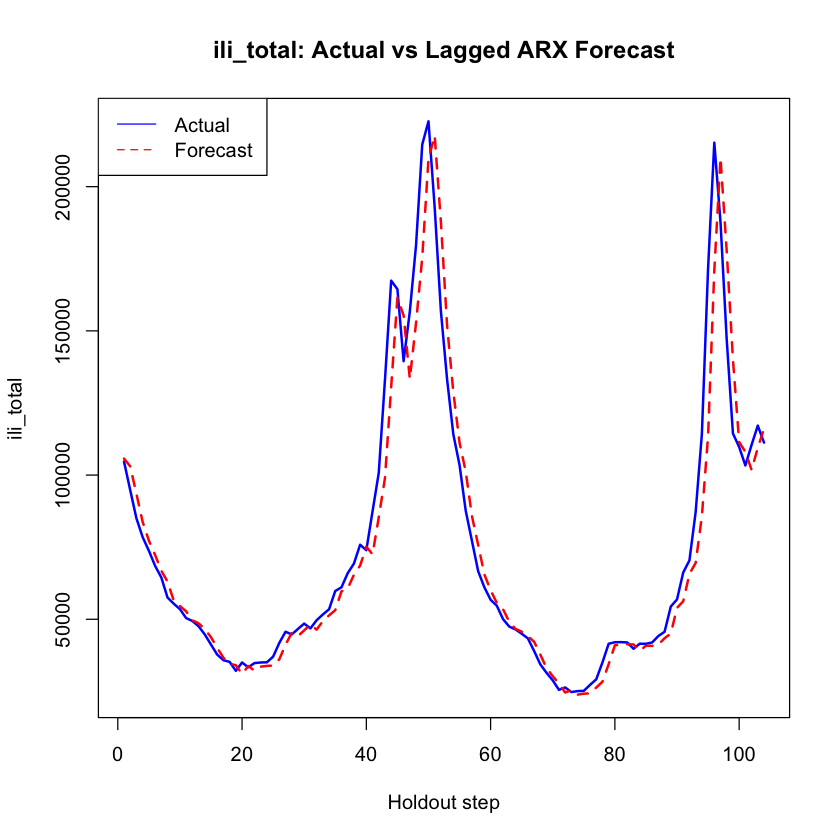

In [4]:
# Plot results
par(mfrow = c(1, 1))
actuals_original <- expm1(actuals)
forecasts_original <- expm1(forecasts)

plot(1:holdout_length, actuals_original, type = "l", col = "blue", lwd = 2,
     main = "ili_total: Actual vs Lagged ARX Forecast", 
     ylab = "ili_total", xlab = "Holdout step",
     ylim = range(c(actuals_original, forecasts_original)))
lines(1:holdout_length, forecasts_original, col = "red", lty = 2, lwd = 2)
legend("topleft", legend = c("Actual", "Forecast"), col = c("blue", "red"), lty = c(1, 2))